In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv("../data/processed/nifty50_features.csv", index_col="Date", parse_dates=True)
df.head()

,Close,High,Low,Open,Volume,MA5,MA20,Daily_Return,Volatility,RSI14,Target
Date,,,,,,,,,,,
2015-01-30,8808.900391,8996.599609,8775.099609,8996.599609,267300,8884.329883,8529.457520,-0.016024,0.008323,79.062339,0
2015-02-02,8797.400391,8840.799805,8751.099609,8802.500000,210100,8876.690039,8549.555029,-0.001305,0.008466,77.102423,0
2015-02-03,8756.549805,8837.299805,8726.650391,8823.150391,208700,8845.900000,8568.462500,-0.004643,0.008815,75.612041,0
2015-02-04,8723.700195,8792.849609,8704.400391,8789.150391,195300,8807.780078,8598.280005,-0.003751,0.007329,74.691503,0
2015-02-05,8711.700195,8838.450195,8683.650391,8733.099609,173600,8759.650195,8628.760010,-0.001376,0.007234,65.564873,0


In [2]:
FEATURES = ["MA5", "MA20", "RSI14", "Volatility"]  # dropping raw Close — redundant with MA5/MA20
TARGET = "Target"

split_idx = int(len(df) * 0.8)  # 80% train, 20% test, in time order

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Train: {X_train.shape}, {train.index.min()} to {train.index.max()}")
print(f"Test:  {X_test.shape}, {test.index.min()} to {test.index.max()}")

Train: (2151, 4), 2015-01-30 00:00:00 to 2023-10-26 00:00:00
Test:  (538, 4), 2023-10-27 00:00:00 to 2025-12-31 00:00:00


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [5]:
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"Baseline (majority class): {y_test.mean() if y_test.mean() > 0.5 else 1 - y_test.mean():.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.5409
Baseline (majority class): 0.5372

              precision    recall  f1-score   support

           0       0.57      0.03      0.06       249
           1       0.54      0.98      0.70       289

    accuracy                           0.54       538
   macro avg       0.56      0.51      0.38       538
weighted avg       0.55      0.54      0.40       538



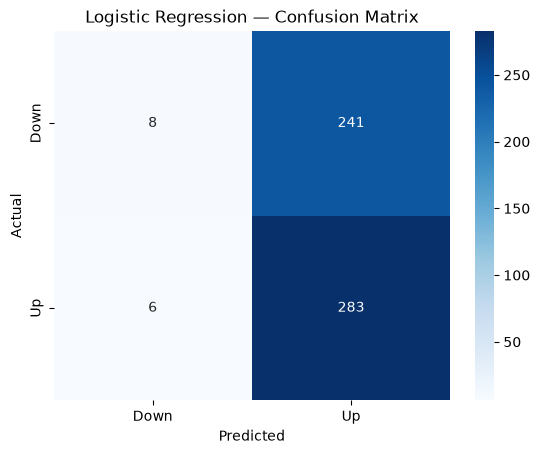

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Down","Up"], yticklabels=["Down","Up"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [7]:
coef_df = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
0,MA5,-0.171556
1,MA20,0.171418
2,RSI14,0.087866
3,Volatility,0.010556


In [8]:
import json

results = {
    "model": "Logistic Regression",
    "accuracy": float(acc),
    "baseline": float(y_test.mean() if y_test.mean() > 0.5 else 1 - y_test.mean())
}

with open("../data/processed/results_logistic_regression.json", "w") as f:
    json.dump(results, f, indent=2)

In [9]:
model_balanced = LogisticRegression(random_state=42, class_weight="balanced")
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

print(f"Accuracy (balanced): {accuracy_score(y_test, y_pred_balanced):.4f}")
print(classification_report(y_test, y_pred_balanced))

Accuracy (balanced): 0.4814
              precision    recall  f1-score   support

           0       0.45      0.51      0.48       249
           1       0.52      0.45      0.48       289

    accuracy                           0.48       538
   macro avg       0.48      0.48      0.48       538
weighted avg       0.49      0.48      0.48       538



In [10]:
results_balanced = {
    "model": "Logistic Regression (balanced)",
    "accuracy": float(accuracy_score(y_test, y_pred_balanced)),
    "baseline": float(y_test.mean() if y_test.mean() > 0.5 else 1 - y_test.mean())
}

with open("../data/processed/results_logistic_regression_balanced.json", "w") as f:
    json.dump(results_balanced, f, indent=2)